In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries(in).csv")

print(f"Total matches in CSV: {len(matches)}")
print(f"Matches shape: {matches.shape}")     
print(f"\nColumn names:\n{matches.columns.tolist()}")

Total matches in CSV: 1095
Matches shape: (1095, 20)

Column names:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


In [ ]:
# Convert date column to datetime
matches['date'] = pd.to_datetime(matches['date'])

# Remove matches with no result (no winner decided)
matches = matches[matches['winner'].notna()]

matches['team1'] = matches['team1'].str.strip()
matches['team2'] = matches['team2'].str.strip()
matches['winner'] = matches['winner'].str.strip()
matches['toss_winner'] = matches['toss_winner'].str.strip()

print(f"Matches with winners: {len(matches)}")
print(f"Matches excluded (no result): {len(pd.read_csv('matches.csv')) - len(matches)}")

Matches with winners: 1090
Matches excluded (no result): 5


In [ ]:

matches['season_year'] = matches['date'].dt.year

# Feature 1: Did toss winner win the match?
matches['toss_win_match_win'] = (matches['toss_winner'] == matches['winner']).astype(int)
toss_win_rate = matches['toss_win_match_win'].value_counts(normalize=True).sort_index()
print("Toss Winner Match Win Rate:")
print(toss_win_rate)

# Feature 2: Did batting first team win?
matches['bat_first'] = matches['toss_decision'].apply(lambda x: 1 if x == 'bat' else 0)
matches['bat_first_win'] = np.where(
    ((matches['bat_first'] == 1) & (matches['team1'] == matches['winner'])) |
    ((matches['bat_first'] == 0) & (matches['team2'] == matches['winner'])),
    1, 0
)

# Feature 3: Group venues by frequency (keep top 10, group rest as 'Other')
top_venues = matches['venue'].value_counts().head(10).index
matches['venue_grouped'] = matches['venue'].apply(
    lambda x: x if x in top_venues else 'Other'
)
print(f"\nTop 10 Venues: {top_venues.tolist()}")

# Feature 4: Team win indicator
matches['team1_win'] = (matches['winner'] == matches['team1']).astype(int)

Toss Winner Match Win Rate:
toss_win_match_win
0    0.491743
1    0.508257
Name: proportion, dtype: float64

Top 10 Venues: ['Eden Gardens', 'Wankhede Stadium', 'M Chinnaswamy Stadium', 'Feroz Shah Kotla', 'Rajiv Gandhi International Stadium, Uppal', 'MA Chidambaram Stadium, Chepauk', 'Sawai Mansingh Stadium', 'Dubai International Cricket Stadium', 'Wankhede Stadium, Mumbai', 'Punjab Cricket Association Stadium, Mohali']


In [25]:
# Sort matches chronologically
matches = matches.sort_values('date').reset_index(drop=True)

# Calculate form for each team before each match
team_form = {}  # Stores win/loss history for each team
form_list = []  # Stores (team1_form, team2_form) for each match

for idx, row in matches.iterrows():
    team1 = row['team1']
    team2 = row['team2']
    
    # Get form (win % from last 5 matches)
    def get_form(team):
        if team not in team_form:
            return 0.5  # Default neutral form
        history = team_form[team]
        return np.mean(history[-5:]) if len(history) >= 1 else 0.5
    
    form1 = get_form(team1)
    form2 = get_form(team2)
    form_list.append((form1, form2))
    
    # Initialize team in dictionary if not present
    winner = row['winner']
    for team in [team1, team2, winner]:
        if team not in team_form:
            team_form[team] = []
    
    # Update history: winner gets 1, loser gets 0
    team_form[winner].append(1)
    loser = team1 if winner == team2 else team2
    team_form[loser].append(0)

# Add form columns to dataframe
matches['team1_form'] = [f[0] for f in form_list]
matches['team2_form'] = [f[1] for f in form_list]

# Calculate form difference
matches['form_diff'] = matches['team1_form'] - matches['team2_form']

print("Form calculation complete")
print(f"Form difference range: {matches['form_diff'].min():.2f} to {matches['form_diff'].max():.2f}")
print(f"Mean form difference: {matches['form_diff'].mean():.3f}")
cols = ['date', 'team1', 'team2', 'team1_form', 'team2_form', 'form_diff', 'winner']
print(matches[cols].head(10))

Form calculation complete
Form difference range: -1.00 to 1.00
Mean form difference: -0.000
        date                        team1                        team2  \
0 2008-04-18  Royal Challengers Bangalore        Kolkata Knight Riders   
1 2008-04-19              Kings XI Punjab          Chennai Super Kings   
2 2008-04-19             Delhi Daredevils             Rajasthan Royals   
3 2008-04-20               Mumbai Indians  Royal Challengers Bangalore   
4 2008-04-20        Kolkata Knight Riders              Deccan Chargers   
5 2008-04-21             Rajasthan Royals              Kings XI Punjab   
6 2008-04-22              Deccan Chargers             Delhi Daredevils   
7 2008-04-23          Chennai Super Kings               Mumbai Indians   
8 2008-04-24              Deccan Chargers             Rajasthan Royals   
9 2008-04-25              Kings XI Punjab               Mumbai Indians   

   team1_form  team2_form  form_diff                       winner  
0         0.5         0.5

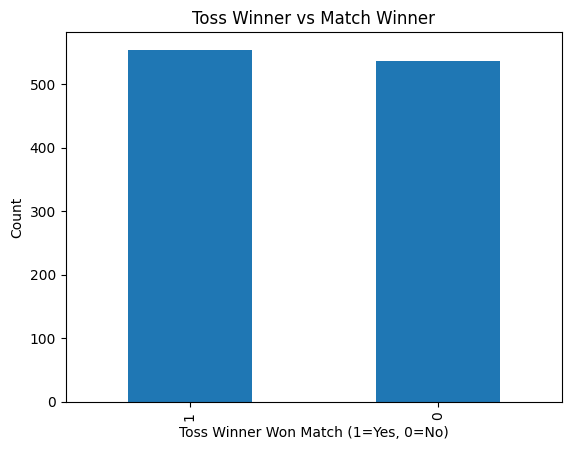

In [19]:
# Chart 1: Does toss winner win the match?
matches['toss_win_match_win'].value_counts().plot(kind='bar')
plt.title("Toss Winner vs Match Winner")
plt.xlabel("Toss Winner Won Match (1=Yes, 0=No)")
plt.ylabel("Count")
plt.show()

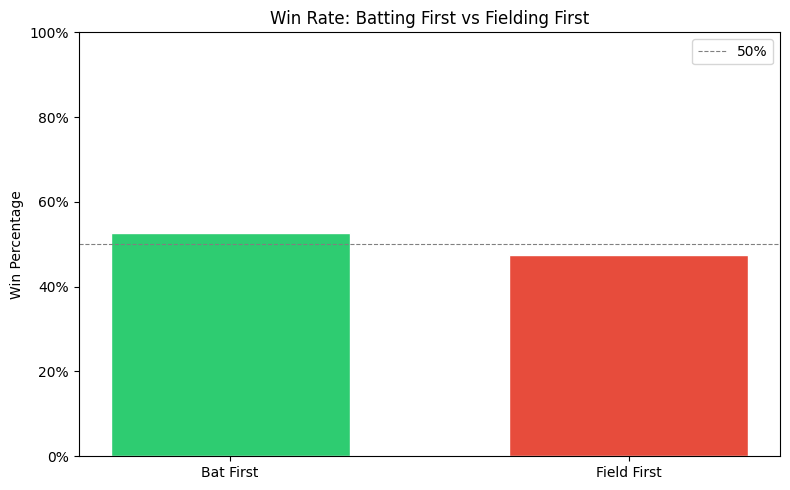

Batting First Win %: 52.57%


In [20]:
# Chart 2: Win rate when batting first vs fielding first
bat_win_rate = matches['bat_first_win'].mean()
field_win_rate = 1 - bat_win_rate

fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Bat First', 'Field First']
rates = [bat_win_rate * 100, field_win_rate * 100]
colors = ['#2ecc71', '#e74c3c']

ax.bar(categories, rates, color=colors, edgecolor='white', width=0.6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, label='50%')
ax.set_ylabel("Win Percentage")
ax.set_title("Win Rate: Batting First vs Fielding First")
ax.set_ylim([0, 100])
plt.legend()
plt.tight_layout()
plt.show()

print(f"Batting First Win %: {bat_win_rate * 100:.2f}%")

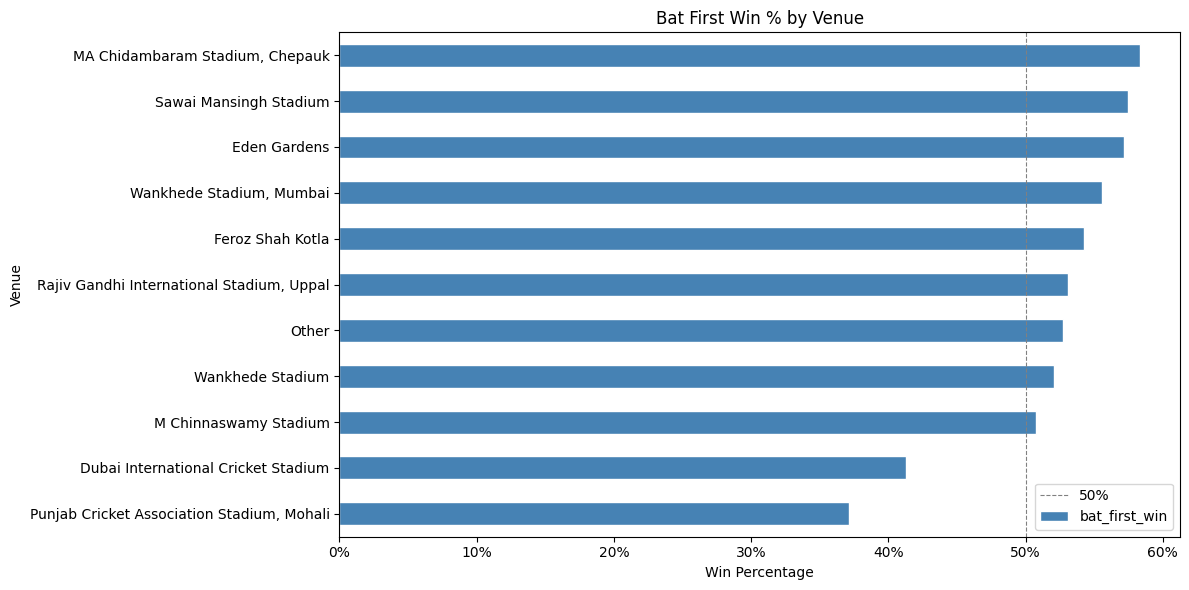

In [21]:
# Chart 3: Bat first win rate by venue
venue_win = matches.groupby('venue_grouped')['bat_first_win'].mean()
venue_win = venue_win.sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
venue_win.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8, label='50%')
ax.set_title("Bat First Win % by Venue")
ax.set_xlabel("Win Percentage")
ax.set_ylabel("Venue")
plt.legend()
plt.tight_layout()
plt.show()

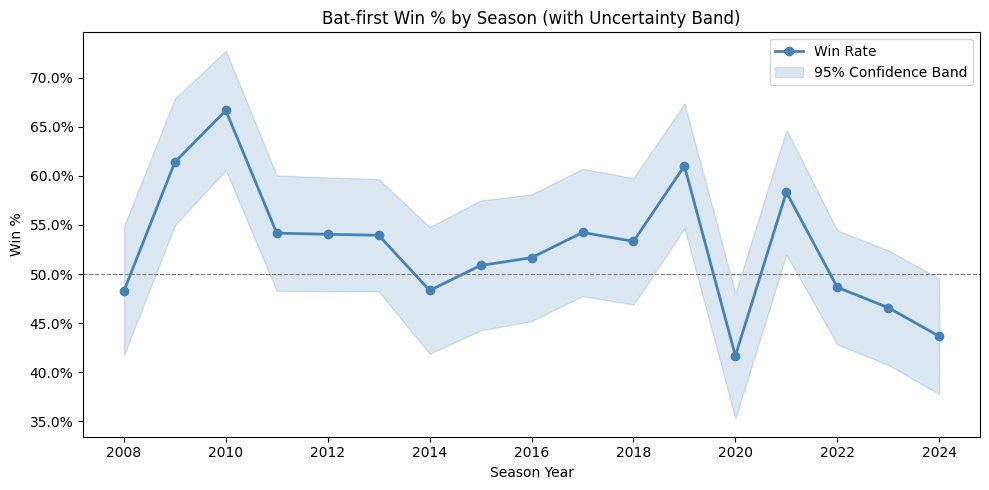

In [22]:
# Chart 4: Season trend with confidence band
season_stats = matches.groupby('season_year').agg(
    win_rate=('bat_first_win','mean'),
    n=('bat_first_win','count')
).reset_index()

# Calculate standard error for confidence bands
season_stats['se'] = np.sqrt(
    season_stats['win_rate'] * (1 - season_stats['win_rate']) / season_stats['n'])

fig, ax = plt.subplots(figsize=(10, 5))

# Plot line and confidence band
ax.plot(season_stats['season_year'], season_stats['win_rate']*100,
        marker='o', color='steelblue', linewidth=2, label='Win Rate')
ax.fill_between(season_stats['season_year'],
    (season_stats['win_rate'] - season_stats['se'])*100,
    (season_stats['win_rate'] + season_stats['se'])*100,
    alpha=0.2, color='steelblue', label='95% Confidence Band')

ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Bat-first Win % by Season (with Uncertainty Band)")
ax.set_xlabel("Season Year")
ax.set_ylabel("Win %")
ax.legend()
plt.tight_layout()
plt.show()

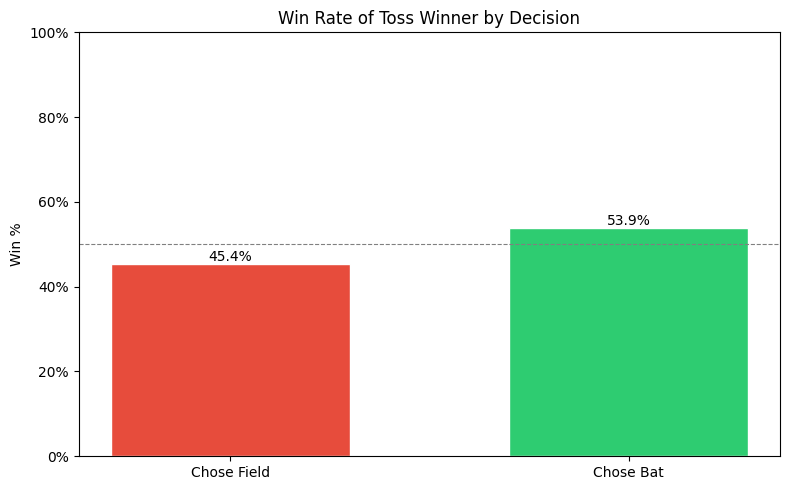

In [23]:
# Chart 5: Toss decision × toss winner outcome
toss_cond = matches.groupby(['toss_decision','toss_win_match_win']).size().unstack(fill_value=0)
toss_cond_pct = toss_cond.div(toss_cond.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5))

# Plot win rate (column 1 = toss winner won match)
win_rates = toss_cond_pct[1]
colors = ['#e74c3c', '#2ecc71']  # Red for field, Green for bat

bars = ax.bar(range(len(win_rates)), win_rates.values, color=colors, edgecolor='white', width=0.6)
ax.set_xticks(range(len(win_rates)))
ax.set_xticklabels(['Chose Field', 'Chose Bat'], rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
ax.set_title("Win Rate of Toss Winner by Decision")
ax.set_ylabel("Win %")
ax.set_ylim([0, 100])

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

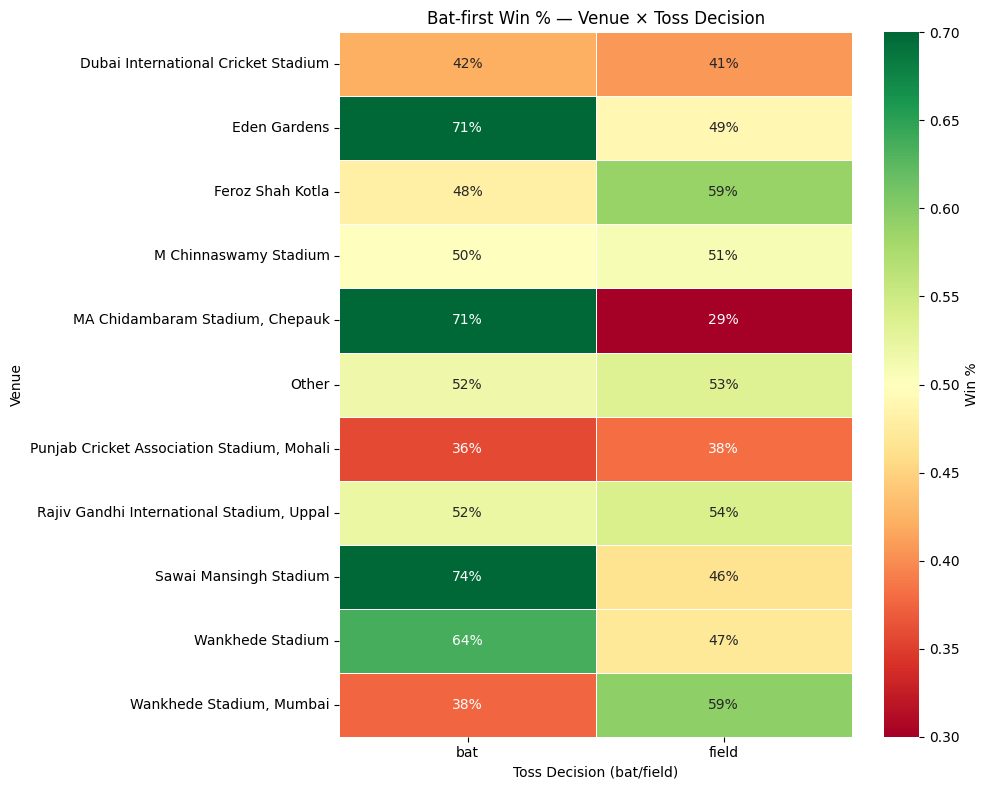


Heatmap shows interaction between venue and toss decision
Green = Bat-first teams win more often
Red = Field-first teams (or chasing teams) win more often


In [ ]:
# Chart 7: Heatmap - Bat first win % by venue and toss decision
heatmap_data = matches.groupby(['venue_grouped','toss_decision'])['bat_first_win'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".0%", cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0.3, vmax=0.7, cbar_kws={'label': 'Win %'})
ax.set_title("Bat-first Win % — Venue × Toss Decision")
ax.set_xlabel("Toss Decision (bat/field)")
ax.set_ylabel("Venue")
plt.tight_layout()
plt.sho
print("\nHeatmap shows interaction between venue and toss decision")
print("Green = Bat-first teams win more often")
print("Red = Field-first teams (or chasing teams) win more often")